#Boosting Techniques | Assignment
## Assignment Code: DA-AG-015

Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.
- Boosting is an ensemble learning technique in machine learning that combines multiple weak learners, typically shallow decision trees, to create a strong predictive model. Unlike bagging, where models are trained independently, boosting trains models sequentially — each new model focuses on correcting the errors made by the previous ones. The idea is to give more weight to the misclassified samples so that the next learner pays more attention to the difficult cases.

- By continuously improving on the previous models' weaknesses, boosting gradually reduces bias and improves overall accuracy. This process turns several weak learners, which perform only slightly better than random guessing, into a powerful model capable of making highly accurate predictions.

---

Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
- The main difference between AdaBoost and Gradient Boosting lies in how they adjust model errors and train subsequent learners.

- AdaBoost (Adaptive Boosting) assigns weights to each training sample and increases the weights of misclassified instances after each iteration, forcing the next weak learner to focus more on these hard examples. It combines learners by weighted voting.

- Gradient Boosting builds learners sequentially by optimizing a loss function using gradient descent. Instead of adjusting weights directly, it fits new models to the residual errors (gradients) of the previous ones.

- AdaBoost modifies sample weights, while Gradient Boosting minimizes prediction errors by using gradients of a chosen loss function. Both methods aim to reduce bias but differ in how they learn from mistakes.

---

Question 3: How does regularization help in XGBoost?
- Regularization in XGBoost (Extreme Gradient Boosting) helps prevent overfitting by controlling model complexity. It introduces both L1 (Lasso) and L2 (Ridge) regularization terms in its objective function. These penalties discourage overly complex trees by reducing the importance of less significant features and shrinking large weight values. L1 regularization can even remove unimportant features by forcing their weights to zero, while L2 smooths the model to ensure stability. This makes XGBoost more robust and generalizable compared to traditional boosting algorithms. Additionally, parameters like max_depth, min_child_weight, subsample, and colsample_bytree act as implicit regularizers that limit the model’s growth and help it perform well on unseen data.

---

Question 4: Why is CatBoost considered efficient for handling categorical data?
- CatBoost (Categorical Boosting) is specifically designed to handle categorical features efficiently without requiring extensive preprocessing such as one-hot encoding or label encoding. It uses a technique called ordered target statistics, where categorical features are converted into numerical values based on target statistics (like mean target value) computed in a way that avoids data leakage. CatBoost also applies symmetric trees and efficient gradient calculations that speed up training and reduce overfitting. By natively supporting categorical variables and automating much of the preprocessing, CatBoost simplifies workflow, saves memory, and often achieves high accuracy even on datasets with many categorical attributes.

---

Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?
- Boosting techniques are widely preferred in real-world applications that require high accuracy and involve complex, non-linear data patterns. In finance, boosting models like XGBoost and LightGBM are used for credit scoring, fraud detection, and risk assessment because they capture subtle relationships in transaction data. In healthcare, they are applied for disease prediction, patient outcome modeling, and medical image classification due to their strong performance on structured data. Marketing and e-commerce industries use boosting for customer segmentation, churn prediction, and recommendation systems. Additionally, boosting is often chosen in Kaggle competitions and real-world analytics tasks because of its superior predictive power, speed, and ability to handle diverse data types better than bagging methods such as Random Forests.

---



In [1]:
'''
Question 6: Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy
'''

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("AdaBoost Classifier Accuracy:", accuracy)


AdaBoost Classifier Accuracy: 0.9707602339181286


In [2]:
'''
Question 7: Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score
'''

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
print("Gradient Boosting Regressor R-squared Score:", r2)


Gradient Boosting Regressor R-squared Score: 0.804992915650479


In [4]:
'''
Question 8: Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy
'''

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore")

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("Test Accuracy:", accuracy)


Best Parameters: {'learning_rate': 0.2}
Test Accuracy: 0.9649122807017544


CatBoost Classifier Accuracy: 0.9649122807017544


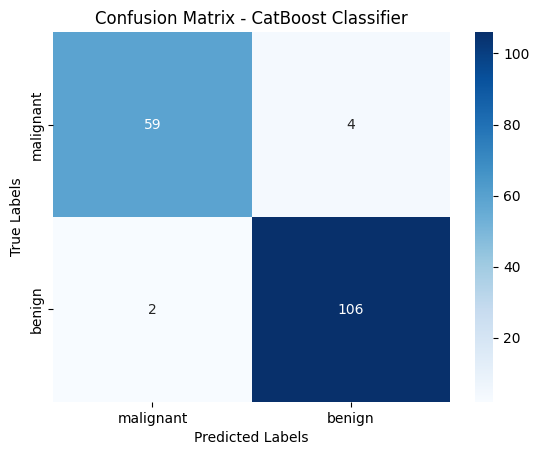

In [7]:
'''
Question 9: Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn
'''

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
# !pip install catboost
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#CatBoost Classifier
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    silent=True,
    random_state=42
    )
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("CatBoost Classifier Accuracy:", accuracy)

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names, yticklabels=data.target_names
    )
plt.title('Confusion Matrix - CatBoost Classifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


---

Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior.


The dataset is imbalanced, contains missing values, and has both numeric and categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
- Data preprocessing & handling missing/categorical values
- Choice between AdaBoost, XGBoost, or CatBoost
- Hyperparameter tuning strategy
- Evaluation metrics you'd choose and why
- How the business would benefit from your model

Answer :  

- Data Preprocessing and Handling Missing/Categorical Values : To begin, I would carefully preprocess the dataset since it contains missing values, categorical features, and an imbalanced target variable. For missing numerical data, I would use median or iterative imputation, while for categorical data, I would use mode imputation or a special “missing” label if the absence of data itself carries information. When encoding categorical variables, I would rely on the model's capabilities — CatBoost can handle them automatically, while XGBoost or AdaBoost would require one-hot or target encoding. I would also ensure that the dataset is split using stratified sampling to maintain class balance across training and testing sets.

- Choice Between AdaBoost, XGBoost, and CatBoost:  Given the nature of the dataset, which includes both numerical and categorical features along with missing values, CatBoost would be my preferred algorithm. CatBoost natively handles categorical data and missing values efficiently, reducing the need for manual preprocessing. XGBoost is another strong choice, especially for numerical data, but it requires additional encoding steps. AdaBoost, while simpler, is more prone to overfitting and generally less effective on complex or imbalanced datasets, so it would be my secondary option.

- Hyperparameter Tuning Strategy : After training a baseline model, I would use GridSearchCV or RandomizedSearchCV to tune hyperparameters such as learning rate, number of estimators, maximum depth, and regularization parameters. I would also use early stopping during training to prevent overfitting. For more efficient optimization, tools like Optuna can be used to automatically search for the best parameter combinations. This systematic tuning ensures that the model achieves the best balance between bias and variance.

- Evaluation Metrics : Since the dataset is imbalanced, I would not rely on accuracy alone. Instead, I would evaluate performance using ROC-AUC and Precision-Recall AUC scores, as they better reflect model performance on imbalanced data. Additionally, I would monitor precision, recall, and F1-score to assess how well the model identifies loan defaulters. I would also tune the classification threshold to minimize financial loss, ensuring that high-risk borrowers are correctly identified. Finally, I would check the model's calibration using metrics like the Brier score to ensure probability outputs are reliable.

- Business Benefits of the Model : Implementing a boosting model provides significant business advantages for a financial institution. It enables early detection of potential loan defaulters, allowing the company to take preventive measures such as revising credit limits or offering repayment assistance. The model also helps optimize loan approval processes, balancing profitability with risk management. Moreover, feature importance and SHAP value analysis make the model's decisions explainable, building trust with regulators and stakeholders. Overall, using boosting techniques enhances predictive accuracy, reduces default rates, and supports more informed and data-driven financial decision-making.

---